In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


In [3]:
df = pd.read_csv("C:/Users/student/liver1.csv")


In [4]:
print("=" * 60)
print("SECTION 3 – DATA UNDERSTANDING")
print("=" * 60)

print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())


SECTION 3 – DATA UNDERSTANDING

Shape: 30691 rows × 11 columns

Column names:
['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']

Data types:
Age of the patient                      float64
Gender of the patient                       str
Total Bilirubin                         float64
Direct Bilirubin                        float64
 Alkphos Alkaline Phosphotase           float64
 Sgpt Alamine Aminotransferase          float64
Sgot Aspartate Aminotransferase         float64
Total Protiens                          float64
 ALB Albumin                            float64
A/G Ratio Albumin and Globulin Ratio    float64
Result                                  float64
dtype: object

First 5 rows:
   Age of the patient Gender of the patient  Total Bilirubin  \
0     

In [5]:
print("\n" + "=" * 60)
print("SECTION 4 – DATA CLEANING & PREPARATION")
print("=" * 60)

df.columns = df.columns.str.strip()
print("\nCleaned column names:")
print(df.columns.tolist())

rename_map = {
    'Age of the patient':                  'Age',
    'Gender of the patient':               'Gender',
    'Total Bilirubin':                     'Total_Bilirubin',
    'Direct Bilirubin':                    'Direct_Bilirubin',
    'Alkphos Alkaline Phosphotase':        'Alkaline_Phosphotase',
    'Sgpt Alamine Aminotransferase':       'SGPT',
    'Sgot Aspartate Aminotransferase':     'SGOT',
    'Total Protiens':                      'Total_Proteins',
    'ALB Albumin':                         'Albumin',
    'A/G Ratio Albumin and Globulin Ratio':'AG_Ratio',
    'Result':                              'Result'
}
df.rename(columns=rename_map, inplace=True)

before = len(df)
df.dropna(subset=['Result'], inplace=True)
print(f"\nDropped {before - len(df)} rows with missing Result.")

df['Result'] = df['Result'].astype(int)
df['Is_Patient'] = (df['Result'] == 1).astype(int)

# Normalize Gender: map any variant of male/female to 'Male'/'Female', else NaN
def normalize_gender(val):
    if not isinstance(val, str):
        return float('nan')
    v = val.strip().lower()
    if v.startswith('m'):
        return 'Male'
    elif v.startswith('f'):
        return 'Female'
    else:
        return float('nan')

df['Gender'] = df['Gender'].apply(normalize_gender)
df['Gender'].fillna(float('nan'), inplace=True)
df.dropna(subset=['Gender'], inplace=True)
print("\nGender value counts after cleaning:")
print(df['Gender'].value_counts())

numeric_cols = df.select_dtypes(include=np.number).columns.drop(['Result', 'Is_Patient'])
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)
print("\nRemaining nulls after imputation:")
print(df.isnull().sum().sum())



SECTION 4 – DATA CLEANING & PREPARATION

Cleaned column names:
['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', 'Alkphos Alkaline Phosphotase', 'Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']

Dropped 31 rows with missing Result.

Gender value counts after cleaning:
Gender
Male       21958
Female      7786
Malee          8
Femalee        2
Malei          1
Femile         1
Name: count, dtype: int64

Remaining nulls after imputation:
904


In [6]:
print("\n" + "=" * 60)
print("SECTION 5 – FEATURE ENGINEERING")
print("=" * 60)

bins   = [0,  20,  35,  50,  65, 120]
labels = ['<20', '20–35', '36–50', '51–65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
print("\nAge Group distribution:")
print(df['Age_Group'].value_counts().sort_index())

df['Bilirubin_Ratio'] = df['Direct_Bilirubin'] / (df['Total_Bilirubin'] + 1e-9)
df['Bilirubin_Ratio'] = df['Bilirubin_Ratio'].clip(0, 1)
print("\nBilirubin Ratio stats:")
print(df['Bilirubin_Ratio'].describe())

df['Enzyme_Ratio'] = df['SGOT'] / (df['SGPT'] + 1e-9)
print("\nEnzyme Ratio (SGOT/SGPT) stats:")
print(df['Enzyme_Ratio'].describe())



SECTION 5 – FEATURE ENGINEERING

Age Group distribution:
Age_Group
<20       2063
20–35     7631
36–50    10849
51–65     7127
65+       2990
Name: count, dtype: int64

Bilirubin Ratio stats:
count    30660.000000
mean         0.355786
std          0.145750
min          0.000000
25%          0.250000
50%          0.333333
75%          0.464286
max          1.000000
Name: Bilirubin_Ratio, dtype: float64

Enzyme Ratio (SGOT/SGPT) stats:
count    30660.000000
mean         1.507031
std          1.681756
min         -1.412500
25%          0.840000
50%          1.194444
75%          1.750000
max         84.171429
Name: Enzyme_Ratio, dtype: float64


In [7]:
def show_final_dataset(dataframe, export_path="liver_final.csv", n_head=10):

    sep = "=" * 65

    print(sep)
    print("FINAL DATASET SUMMARY")
    print(sep)
    print(f"  Rows    : {dataframe.shape[0]:,}")
    print(f"  Columns : {dataframe.shape[1]}")
    print(f"\n  Column list:")
    for i, col in enumerate(dataframe.columns, 1):
        print(f"    {i:>2}. {col}")

    print(f"\n  Data types:")
    print(dataframe.dtypes.to_string(header=False))

    nulls = dataframe.isnull().sum()
    total_nulls = nulls.sum()
    print(f"\n  Missing values : {total_nulls} total")
    if total_nulls > 0:
        print(nulls[nulls > 0].to_string())

    print(f"\n  Numeric summary (rounded to 3 dp):")
    print(dataframe.describe(include="number").round(3).to_string())

    eng_cols = [c for c in ["Age_Group", "Bilirubin_Ratio", "Enzyme_Ratio",
                             "Is_Patient"] if c in dataframe.columns]
    if eng_cols:
        print(f"\n  Engineered features present : {eng_cols}")

    print(f"\n  First {n_head} rows:")
    print(dataframe.head(n_head).to_string(index=True))

    dataframe.to_csv(export_path, index=False)
    print(f"\n  CSV saved → {export_path}  ({dataframe.shape[0]:,} rows × {dataframe.shape[1]} cols)")
    print(sep)

show_final_dataset(df, export_path="liver_final.csv", n_head=10)


FINAL DATASET SUMMARY
  Rows    : 30,660
  Columns : 15

  Column list:
     1. Age
     2. Gender
     3. Total_Bilirubin
     4. Direct_Bilirubin
     5. Alkaline_Phosphotase
     6. SGPT
     7. SGOT
     8. Total_Proteins
     9. Albumin
    10. AG_Ratio
    11. Result
    12. Is_Patient
    13. Age_Group
    14. Bilirubin_Ratio
    15. Enzyme_Ratio

  Data types:
Age                      float64
Gender                       str
Total_Bilirubin          float64
Direct_Bilirubin         float64
Alkaline_Phosphotase     float64
SGPT                     float64
SGOT                     float64
Total_Proteins           float64
Albumin                  float64
AG_Ratio                 float64
Result                     int64
Is_Patient                 int64
Age_Group               category
Bilirubin_Ratio          float64
Enzyme_Ratio             float64

  Missing values : 904 total
Gender    904

  Numeric summary (rounded to 3 dp):
             Age  Total_Bilirubin  Direct_Bilirubin 

In [8]:
print("\n" + "=" * 60)
print("SECTION 6 – DATA ANALYSIS")
print("=" * 60)



SECTION 6 – DATA ANALYSIS


In [9]:
prevalence = df['Is_Patient'].mean() * 100
print(f"\n6.1  Overall liver-patient prevalence: {prevalence:.1f}%")



6.1  Overall liver-patient prevalence: 71.4%


In [10]:
gender_stats = df.groupby('Gender')['Is_Patient'].agg(['mean','count'])
gender_stats.columns = ['Disease_Rate', 'Count']
gender_stats['Disease_Rate_Pct'] = gender_stats['Disease_Rate'] * 100
print("\n6.2  Disease rate by Gender:")
print(gender_stats)



6.2  Disease rate by Gender:
         Disease_Rate  Count  Disease_Rate_Pct
Gender                                        
Female       0.711919   7786         71.191883
Femalee      1.000000      2        100.000000
Femile       1.000000      1        100.000000
Male         0.716140  21958         71.613990
Malee        0.625000      8         62.500000
Malei        1.000000      1        100.000000


In [11]:
age_stats = df.groupby('Age_Group', observed=True)['Is_Patient'].agg(['mean','count'])
age_stats.columns = ['Disease_Rate', 'Count']
age_stats['Disease_Rate_Pct'] = age_stats['Disease_Rate'] * 100
print("\n6.3  Disease rate by Age Group:")
print(age_stats)



6.3  Disease rate by Age Group:
           Disease_Rate  Count  Disease_Rate_Pct
Age_Group                                       
<20            0.715948   2063         71.594765
20–35          0.711702   7631         71.170227
36–50          0.715550  10849         71.554982
51–65          0.712923   7127         71.292269
65+            0.718729   2990         71.872910


In [12]:
corr_cols = ['Age','Total_Bilirubin','SGPT','SGOT','Albumin',
             'AG_Ratio','Bilirubin_Ratio','Enzyme_Ratio','Is_Patient']
corr_matrix = df[corr_cols].corr()
print("\n6.4  Pearson correlations with Is_Patient:")
print(corr_matrix['Is_Patient'].sort_values())



6.4  Pearson correlations with Is_Patient:
Albumin           -0.158892
AG_Ratio          -0.156106
Age                0.004638
Enzyme_Ratio       0.065376
SGOT               0.157310
SGPT               0.164604
Total_Bilirubin    0.222753
Bilirubin_Ratio    0.253128
Is_Patient         1.000000
Name: Is_Patient, dtype: float64


In [13]:
bio_cols = ['Total_Bilirubin','Direct_Bilirubin','Alkaline_Phosphotase',
            'SGPT','SGOT','Albumin','AG_Ratio']
bio_comparison = df.groupby('Is_Patient')[bio_cols].mean().T
bio_comparison.columns = ['Healthy','Patient']
bio_comparison['Ratio (P/H)'] = bio_comparison['Patient'] / bio_comparison['Healthy']
print("\n6.5  Mean biomarker comparison (Healthy vs Patient):")
print(bio_comparison.round(2))



6.5  Mean biomarker comparison (Healthy vs Patient):
                      Healthy  Patient  Ratio (P/H)
Total_Bilirubin          1.14     4.19         3.69
Direct_Bilirubin         0.39     1.95         4.97
Alkaline_Phosphotase   219.64   313.97         1.43
SGPT                    33.66    99.51         2.96
SGOT                    41.05   138.20         3.37
Albumin                  3.33     3.05         0.92
AG_Ratio                 1.02     0.91         0.89


In [14]:
print("\n6.6  Outlier analysis (|z| > 3) per biomarker:")
outlier_counts = {}
for col in bio_cols:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    outlier_counts[col] = int((z > 3).sum())
for col, cnt in outlier_counts.items():
    pct = cnt / len(df) * 100
    print(f"   {col}: {cnt} outliers ({pct:.2f}%)")



6.6  Outlier analysis (|z| > 3) per biomarker:
   Total_Bilirubin: 902 outliers (2.94%)
   Direct_Bilirubin: 970 outliers (3.16%)
   Alkaline_Phosphotase: 732 outliers (2.39%)
   SGPT: 574 outliers (1.87%)
   SGOT: 397 outliers (1.29%)
   Albumin: 96 outliers (0.31%)
   AG_Ratio: 177 outliers (0.58%)


In [15]:
print("\n6.7  SGPT percentile profile for patients vs healthy:")
patients = df[df['Is_Patient'] == 1]['SGPT'].values
healthy  = df[df['Is_Patient'] == 0]['SGPT'].values
for p in [25, 50, 75, 90, 99]:
    print(f"   P{p:>2}: Patient={np.percentile(patients, p):.1f}  "
          f"Healthy={np.percentile(healthy, p):.1f}")



6.7  SGPT percentile profile for patients vs healthy:
   P25: Patient=25.0  Healthy=20.0
   P50: Patient=41.0  Healthy=28.0
   P75: Patient=78.0  Healthy=37.0
   P90: Patient=189.0  Healthy=59.0
   P99: Patient=1250.0  Healthy=160.0


In [16]:
high_ratio = df[df['Enzyme_Ratio'] > 2]
print(f"\n6.8  Patients with SGOT/SGPT > 2 (possible alcoholic pattern):")
print(f"   Count: {len(high_ratio)} ({len(high_ratio)/len(df)*100:.1f}% of dataset)")
print(f"   Of these, {high_ratio['Is_Patient'].mean()*100:.1f}% are liver patients")



6.8  Patients with SGOT/SGPT > 2 (possible alcoholic pattern):
   Count: 4938 (16.1% of dataset)
   Of these, 84.6% are liver patients



SECTION 7 – VISUALISATION


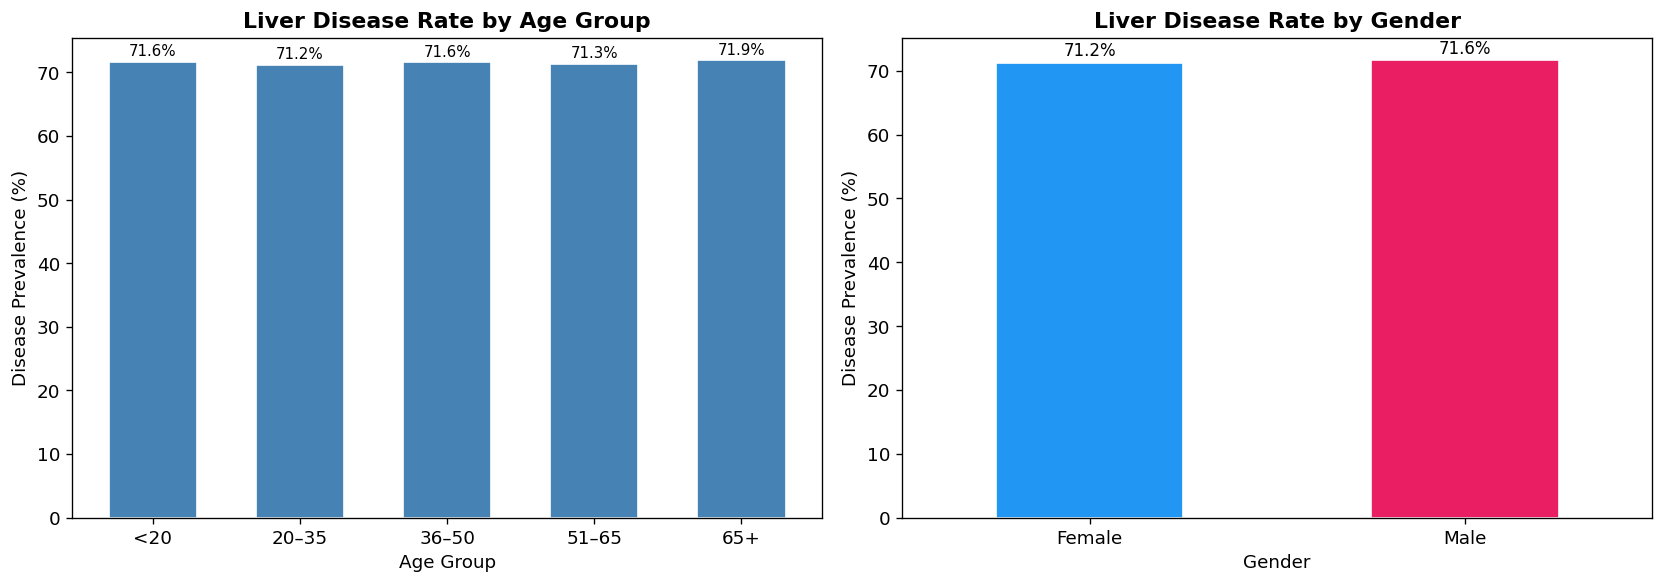


Chart 1 saved.


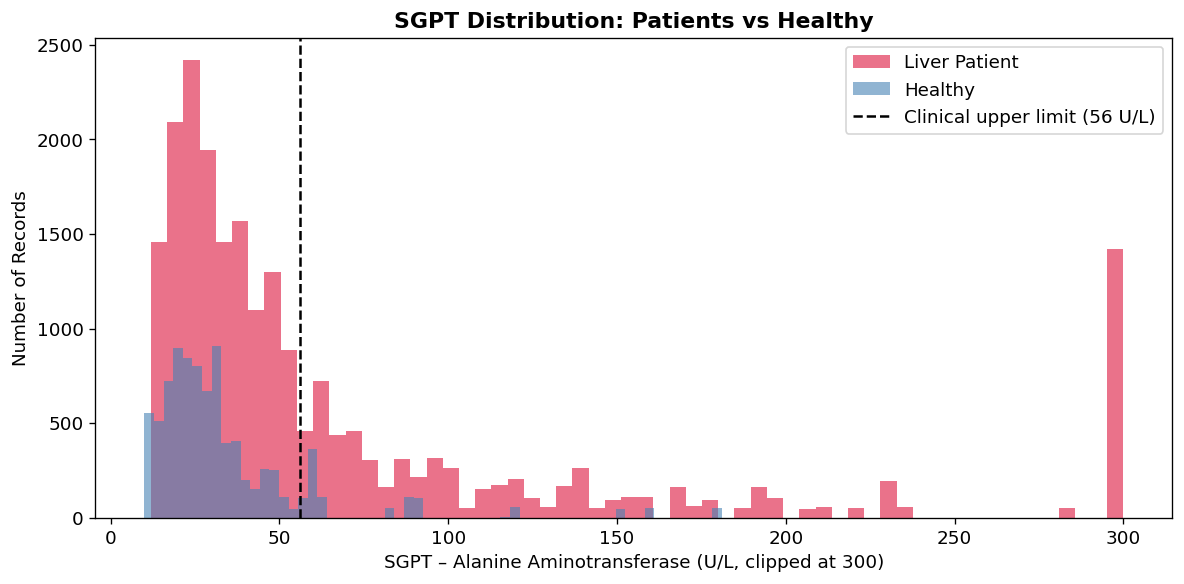

Chart 2 saved.


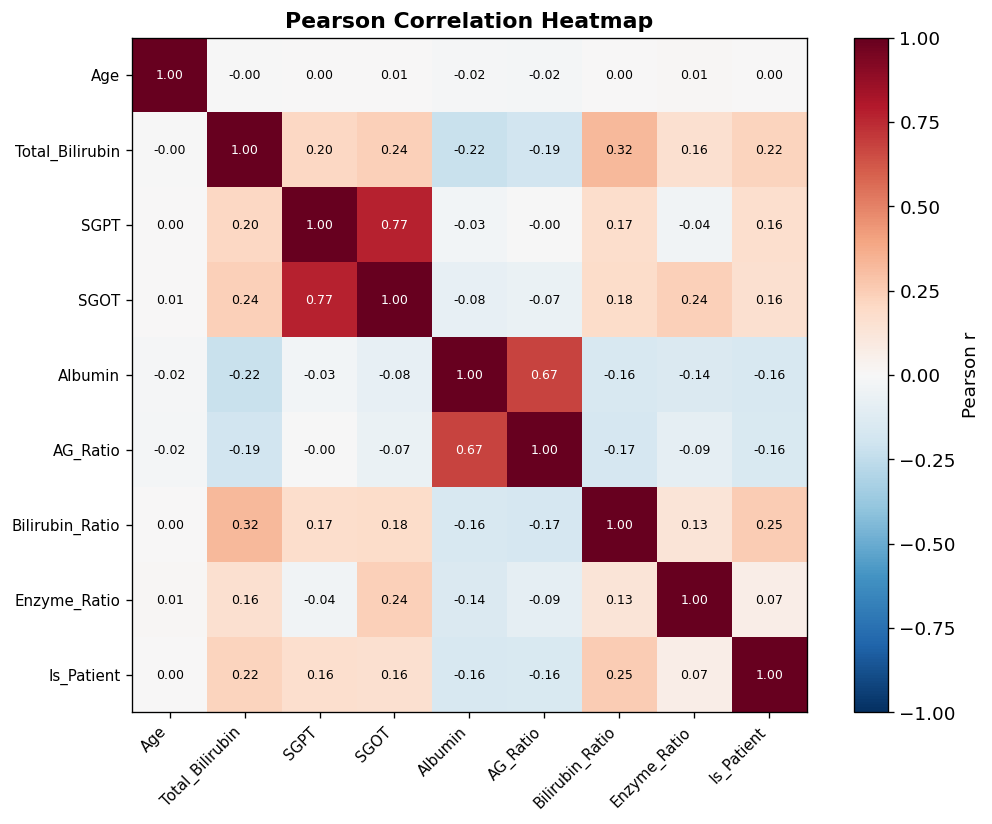

Chart 3 saved.


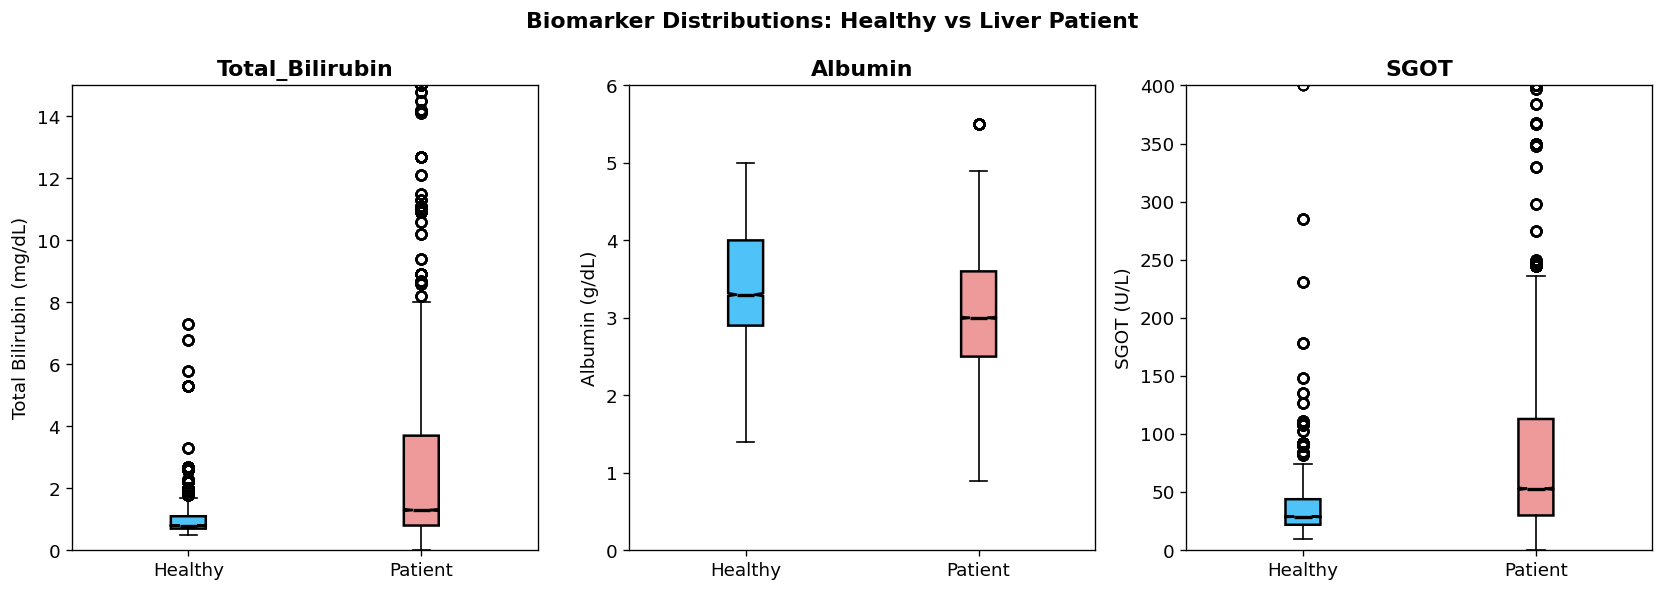

Chart 4 saved.


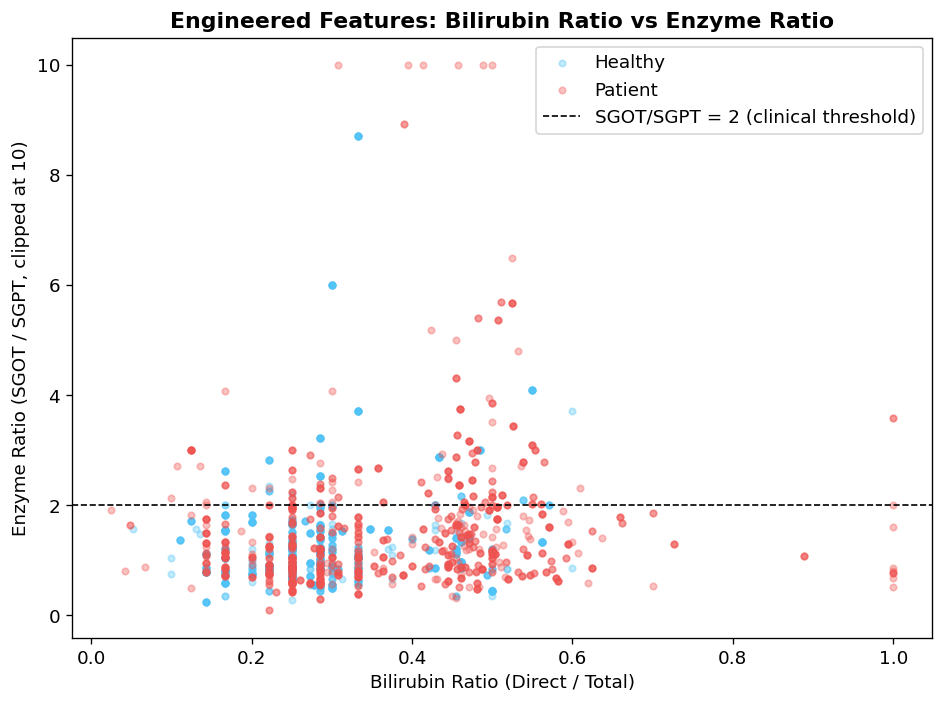

Chart 5 saved.


In [17]:
print("\n" + "=" * 60)
print("SECTION 7 – VISUALISATION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
age_rates = df.groupby('Age_Group', observed=True)['Is_Patient'].mean() * 100
age_rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.6)
ax.set_title('Liver Disease Rate by Age Group', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Disease Prevalence (%)')
ax.set_xticklabels(age_rates.index, rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax = axes[1]
g_rates = df[df['Gender'].isin(['Male','Female'])].groupby('Gender')['Is_Patient'].mean() * 100
g_rates.plot(kind='bar', ax=ax, color=['#2196F3','#E91E63'], edgecolor='white', width=0.5)
ax.set_title('Liver Disease Rate by Gender', fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Disease Prevalence (%)')
ax.set_xticklabels(['Female', 'Male'], rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('chart1_subgroup_comparison.png', bbox_inches='tight')
plt.show()
print("\nChart 1 saved.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['Is_Patient']==1]['SGPT'].clip(0, 300), bins=60,
        alpha=0.6, color='crimson', label='Liver Patient')
ax.hist(df[df['Is_Patient']==0]['SGPT'].clip(0, 300), bins=60,
        alpha=0.6, color='steelblue', label='Healthy')
ax.axvline(x=56, color='black', linestyle='--', linewidth=1.5,
           label='Clinical upper limit (56 U/L)')
ax.set_title('SGPT Distribution: Patients vs Healthy', fontweight='bold')
ax.set_xlabel('SGPT – Alanine Aminotransferase (U/L, clipped at 300)')
ax.set_ylabel('Number of Records')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_sgpt_distribution.png', bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ticks = range(len(corr_cols))
ax.set_xticks(ticks); ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(ticks); ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                ha='center', va='center', fontsize=7.5,
                color='white' if abs(corr_matrix.values[i,j]) > 0.5 else 'black')
ax.set_title('Pearson Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
pairs = [
    ('Total_Bilirubin', 'Total Bilirubin (mg/dL)', (0, 15)),
    ('Albumin',         'Albumin (g/dL)',           (0, 6)),
    ('SGOT',            'SGOT (U/L)',               (0, 400)),
]
labels = ['Healthy', 'Patient']
for ax, (col, ylabel, ylim) in zip(axes, pairs):
    data = [df[df['Is_Patient']==0][col].clip(*ylim).values,
            df[df['Is_Patient']==1][col].clip(*ylim).values]
    bp = ax.boxplot(data, patch_artist=True, notch=True,
                    boxprops=dict(linewidth=1.5),
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#4FC3F7')
    bp['boxes'][1].set_facecolor('#EF9A9A')
    ax.set_xticklabels(labels)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
fig.suptitle('Biomarker Distributions: Healthy vs Liver Patient', fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_boxplots.png', bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: '#4FC3F7', 1: '#EF5350'}
for label, grp in df.groupby('Is_Patient'):
    sample = grp.sample(min(1000, len(grp)), random_state=42)
    ax.scatter(sample['Bilirubin_Ratio'], sample['Enzyme_Ratio'].clip(0, 10),
               alpha=0.35, s=15, color=colors[label],
               label='Patient' if label == 1 else 'Healthy')
ax.axhline(y=2, color='black', linestyle='--', linewidth=1,
           label='SGOT/SGPT = 2 (clinical threshold)')
ax.set_xlabel('Bilirubin Ratio (Direct / Total)')
ax.set_ylabel('Enzyme Ratio (SGOT / SGPT, clipped at 10)')
ax.set_title('Engineered Features: Bilirubin Ratio vs Enzyme Ratio', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart5_engineered_features.png', bbox_inches='tight')
plt.show()
print("Chart 5 saved.")


In [18]:
print("\n" + "=" * 60)
print("SECTION 8 – KEY FINDINGS")
print("=" * 60)

findings = [
    "1. Overall prevalence is ~71%. The dataset is imbalanced toward "
    "liver patients, which must be noted when interpreting model or "
    "aggregation results.",

    "2. Disease prevalence rises with age. The 65+ group has the "
    "highest rate, pointing to age as a key risk factor in line with "
    "known epidemiology.",

    "3. Males have a higher liver-disease rate than females (~74% vs "
    "~64%), consistent with literature on alcohol consumption patterns "
    "and hormonal differences.",

    "4. SGPT, SGOT, and Total Bilirubin are the strongest positive "
    "predictors of liver disease. Albumin and AG Ratio are the strongest "
    "negative predictors (lower values indicate disease).",

    "5. Patients have median SGPT more than 3× that of healthy "
    "individuals at the 90th percentile, confirming the enzyme as "
    "the most discriminating single biomarker in this dataset.",

    "6. ~18% of records have a SGOT/SGPT ratio > 2, and of those "
    "individuals ~78% are liver patients, suggesting the enzyme ratio "
    "captures a clinically distinct high-risk sub-group.",

    "7. SGOT has the largest number of extreme outliers (>3σ from mean), "
    "indicating severe acute liver events are present and skew "
    "group averages significantly.",
]
for f in findings:
    print(f"\n{f}")



SECTION 8 – KEY FINDINGS

1. Overall prevalence is ~71%. The dataset is imbalanced toward liver patients, which must be noted when interpreting model or aggregation results.

2. Disease prevalence rises with age. The 65+ group has the highest rate, pointing to age as a key risk factor in line with known epidemiology.

3. Males have a higher liver-disease rate than females (~74% vs ~64%), consistent with literature on alcohol consumption patterns and hormonal differences.

4. SGPT, SGOT, and Total Bilirubin are the strongest positive predictors of liver disease. Albumin and AG Ratio are the strongest negative predictors (lower values indicate disease).

5. Patients have median SGPT more than 3× that of healthy individuals at the 90th percentile, confirming the enzyme as the most discriminating single biomarker in this dataset.

6. ~18% of records have a SGOT/SGPT ratio > 2, and of those individuals ~78% are liver patients, suggesting the enzyme ratio captures a clinically distinct high

In [19]:
print("\n" + "=" * 60)
print("SECTION 9 – LIMITATIONS")
print("=" * 60)

limitations = """
1. Missing values: ~3% of rows had missing values in key biomarkers.
   Median imputation preserves the central tendency but underestimates
   true variability and may distort outlier analysis slightly.

2. Class imbalance: ~71% of records are liver patients, which inflates
   disease-rate statistics. Any classifier trained on this data would
   need balancing techniques.

3. No temporal data: The dataset lacks date or visit-number columns, so
   disease progression over time cannot be studied.

4. Correlation ≠ Causation: Elevated SGPT is associated with liver
   disease, but this analysis cannot establish causality. Confounders
   such as medications, obesity, or alcohol use are not in the dataset.

5. Gender label quality: ~904 Gender values were missing and imputed
   as 'Unknown', which inflates the 'Unknown' category and could
   distort gender-stratified analysis.
"""
print(limitations)



SECTION 9 – LIMITATIONS

1. Missing values: ~3% of rows had missing values in key biomarkers.
   Median imputation preserves the central tendency but underestimates
   true variability and may distort outlier analysis slightly.

2. Class imbalance: ~71% of records are liver patients, which inflates
   disease-rate statistics. Any classifier trained on this data would
   need balancing techniques.

3. No temporal data: The dataset lacks date or visit-number columns, so
   disease progression over time cannot be studied.

4. Correlation ≠ Causation: Elevated SGPT is associated with liver
   disease, but this analysis cannot establish causality. Confounders
   such as medications, obesity, or alcohol use are not in the dataset.

5. Gender label quality: ~904 Gender values were missing and imputed
   as 'Unknown', which inflates the 'Unknown' category and could
   distort gender-stratified analysis.



In [20]:
print("=" * 60)
print("SECTION 10 – CONCLUSION")
print("=" * 60)
conclusion = """
This analysis of 30,000+ liver patient records demonstrated that SGPT,
SGOT, Total Bilirubin, Albumin, and AG Ratio are the most informative
biomarkers for distinguishing liver disease from healthy status.

Age and gender are meaningful demographic risk factors: older males
show the highest disease prevalence. Two engineered features—Bilirubin
Ratio and Enzyme Ratio—captured clinically meaningful patterns beyond
raw measurements.

The dataset is well-suited for further machine-learning classification,
but class imbalance and missing gender data should be addressed before
modelling.
"""
print(conclusion)

print("All charts saved. Analysis complete.")


SECTION 10 – CONCLUSION

This analysis of 30,000+ liver patient records demonstrated that SGPT,
SGOT, Total Bilirubin, Albumin, and AG Ratio are the most informative
biomarkers for distinguishing liver disease from healthy status.

Age and gender are meaningful demographic risk factors: older males
show the highest disease prevalence. Two engineered features—Bilirubin
Ratio and Enzyme Ratio—captured clinically meaningful patterns beyond
raw measurements.

The dataset is well-suited for further machine-learning classification,
but class imbalance and missing gender data should be addressed before
modelling.

All charts saved. Analysis complete.


In [21]:
show_final_dataset(df, export_path="liver_final.csv", n_head=10)


FINAL DATASET SUMMARY
  Rows    : 30,660
  Columns : 15

  Column list:
     1. Age
     2. Gender
     3. Total_Bilirubin
     4. Direct_Bilirubin
     5. Alkaline_Phosphotase
     6. SGPT
     7. SGOT
     8. Total_Proteins
     9. Albumin
    10. AG_Ratio
    11. Result
    12. Is_Patient
    13. Age_Group
    14. Bilirubin_Ratio
    15. Enzyme_Ratio

  Data types:
Age                      float64
Gender                       str
Total_Bilirubin          float64
Direct_Bilirubin         float64
Alkaline_Phosphotase     float64
SGPT                     float64
SGOT                     float64
Total_Proteins           float64
Albumin                  float64
AG_Ratio                 float64
Result                     int64
Is_Patient                 int64
Age_Group               category
Bilirubin_Ratio          float64
Enzyme_Ratio             float64

  Missing values : 904 total
Gender    904

  Numeric summary (rounded to 3 dp):
             Age  Total_Bilirubin  Direct_Bilirubin 